# Monocle Pancreas — Exploratory Notebook

This notebook:
1. Loads and preprocesses the scVelo pancreas dataset
2. Plots cells coloured by cluster in UMAP space
3. Explains and visualises root cell selection
4. Runs Monocle3 pseudotime and plots the result

In [3]:
alpha = 1
print(f"Pseudotime: $\\alpha$ = {alpha}")

Pseudotime: $\alpha$ = 1


In [1]:
import sys
import os
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
TRAVELER_ROOT = NOTEBOOK_DIR.parents[1]
sys.path.insert(0, str(TRAVELER_ROOT / 'py_monocle'))

DATA_FILE = TRAVELER_ROOT / 'data' / 'pancreas.h5ad'

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from py_monocle import learn_graph, order_cells

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

## 1. Load and preprocess

In [2]:
adata = sc.read(str(DATA_FILE))
print(adata)
print('\nObs columns:', adata.obs.columns.tolist())
print('Obsm keys:  ', list(adata.obsm.keys()))

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

Obs columns: ['clusters_coarse', 'clusters', 'S_score', 'G2M_score']
Obsm keys:   ['X_pca', 'X_umap']


/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/anndata/compat/__init__.py:329: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/anndata/compat/__init__.py:329: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


In [3]:
sc.pp.filter_genes(adata, min_counts=20)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)

sc.tl.pca(adata, random_state=42)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=10, random_state=42)
sc.tl.umap(adata, random_state=42)

print('Preprocessing done.')

/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Preprocessing done.


## 2. Cells coloured by cluster (UMAP)

The pancreas dataset comes with `clusters` labels for all developmental stages: Ductal, Ngn3 low/high EP, Pre-endocrine, Beta, Alpha, Delta, Epsilon.

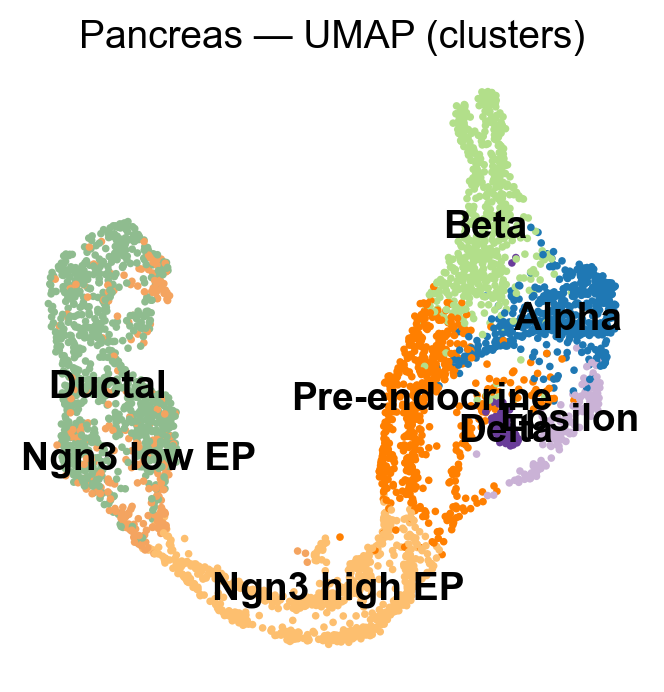

In [4]:
sc.pl.umap(adata, color='clusters', legend_loc='on data',
           title='Pancreas — UMAP (clusters)', frameon=False, size=30)

## 3. Root cell selection

For Monocle3 we select the root from **UMAP space**:

1. Take cells in the **left half** of UMAP x (i.e. `x < mean(x)`)
2. Within those, select the cell with the **highest UMAP y**

**Why?**  
In the pancreas UMAP, Ductal cells (the most primitive progenitors that give rise to all endocrine lineages) cluster in the left portion of the plot at the top. This heuristic is UMAP-space consistent — since Monocle3 itself builds its principal graph in UMAP space, it makes sense to anchor the pseudotime in the same coordinate system.

In [5]:
umap = adata.obsm['X_umap']

mask = umap[:, 0] < umap[:, 0].mean()
passed_indices = np.where(mask)[0]
sub_argmax = umap[mask, 1].argmax()
root = int(passed_indices[sub_argmax])

print(f'Root cell index : {root}')
print(f'UMAP coordinates: {umap[root]}')
if 'clusters' in adata.obs.columns:
    print(f'Cluster label   : {adata.obs["clusters"].iloc[root]}')

Root cell index : 732
UMAP coordinates: [-3.1114793 13.060017 ]
Cluster label   : Ductal


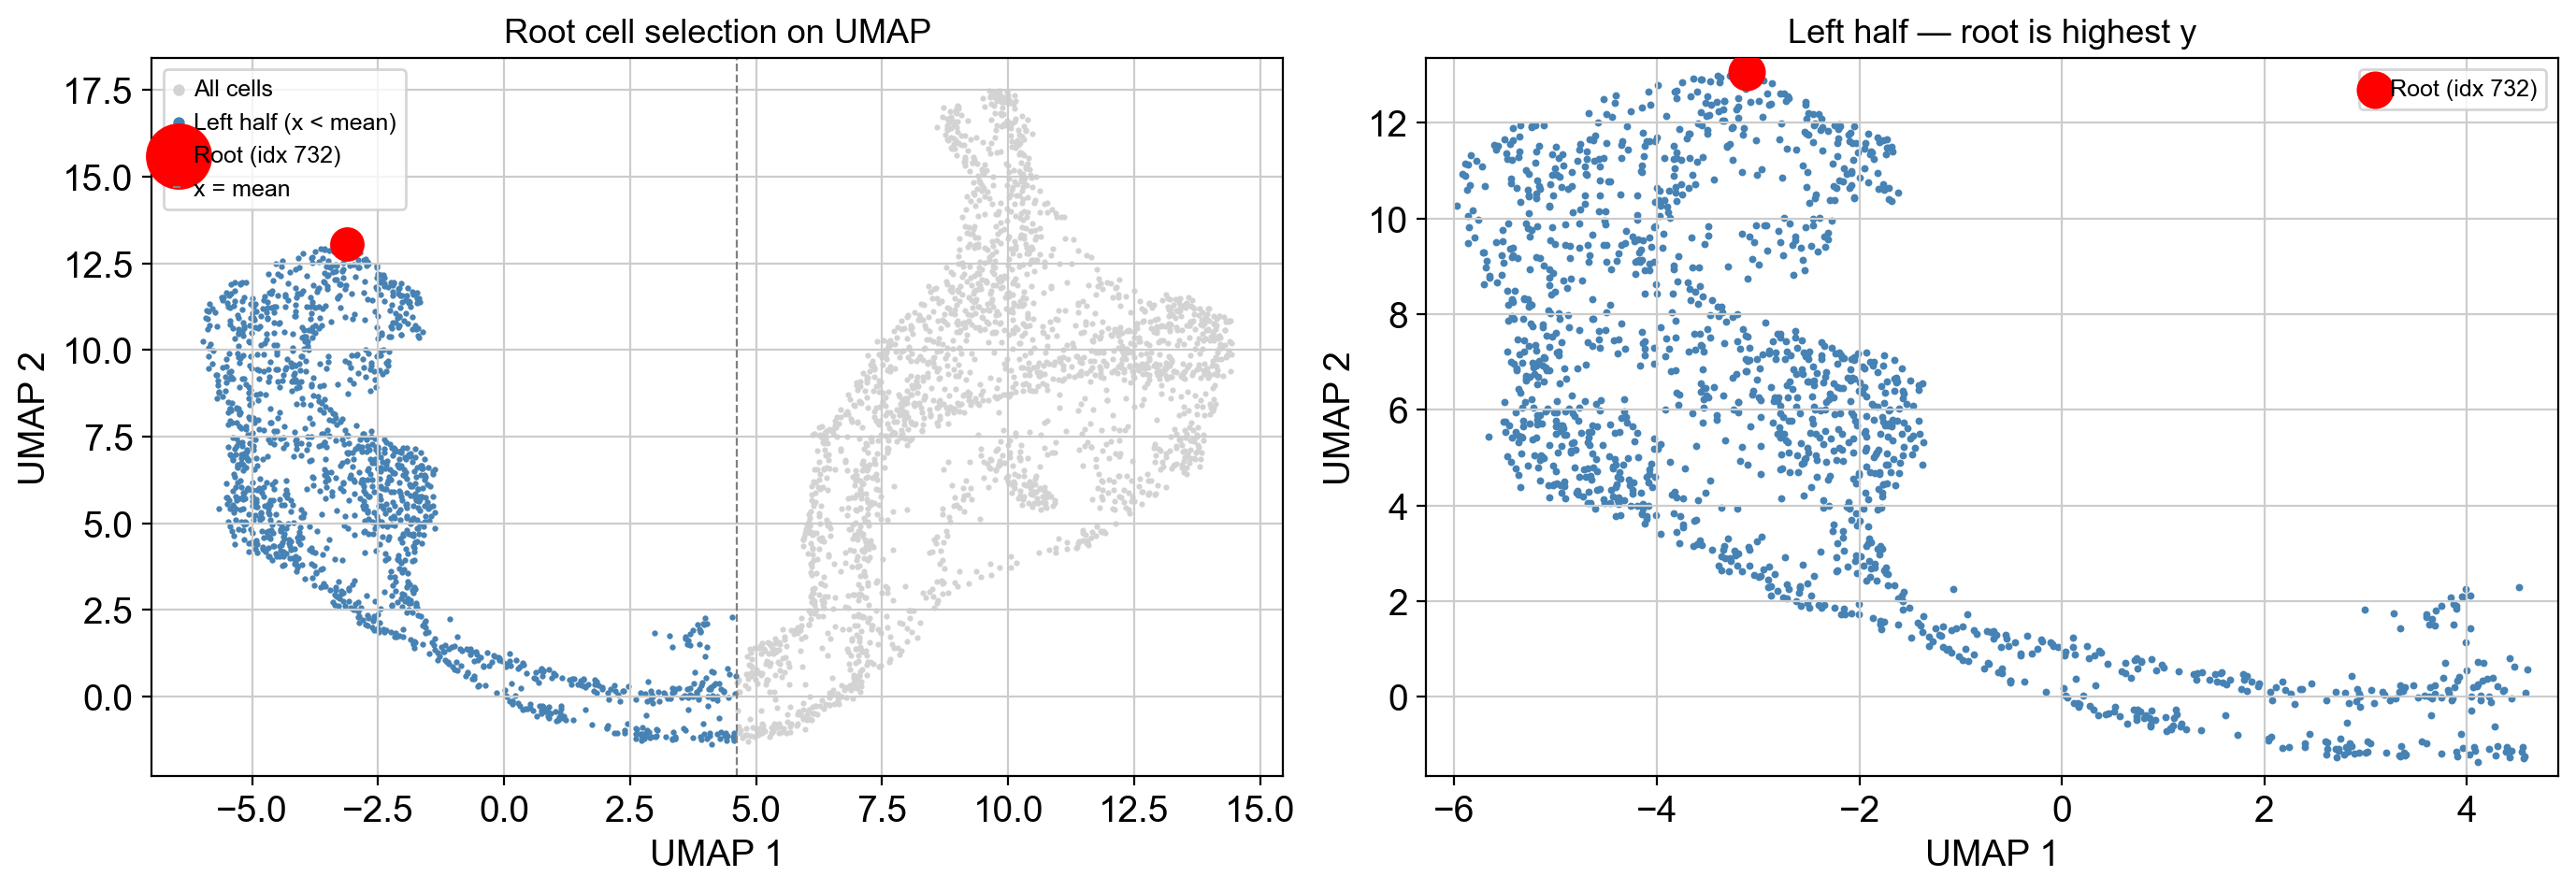

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Show selection region
axes[0].scatter(umap[:, 0], umap[:, 1], s=5, c='lightgrey', linewidths=0, label='All cells')
axes[0].scatter(umap[mask, 0], umap[mask, 1], s=5, c='steelblue', linewidths=0, label='Left half (x < mean)')
axes[0].scatter(umap[root, 0], umap[root, 1], s=150, c='red', zorder=6, label=f'Root (idx {root})')
axes[0].axvline(umap[:, 0].mean(), ls='--', lw=0.8, c='grey', label='x = mean')
axes[0].set_title('Root cell selection on UMAP', fontsize=13)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].legend(fontsize=9, markerscale=2)

# Zoom in on left half
left_umap = umap[mask]
margin = 0.3
axes[1].scatter(left_umap[:, 0], left_umap[:, 1], s=8, c='steelblue', linewidths=0)
axes[1].scatter(umap[root, 0], umap[root, 1], s=180, c='red', zorder=6, label=f'Root (idx {root})')
axes[1].set_xlim(left_umap[:, 0].min() - margin, left_umap[:, 0].max() + margin)
axes[1].set_ylim(left_umap[:, 1].min() - margin, left_umap[:, 1].max() + margin)
axes[1].set_title('Left half — root is highest y', fontsize=13)
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

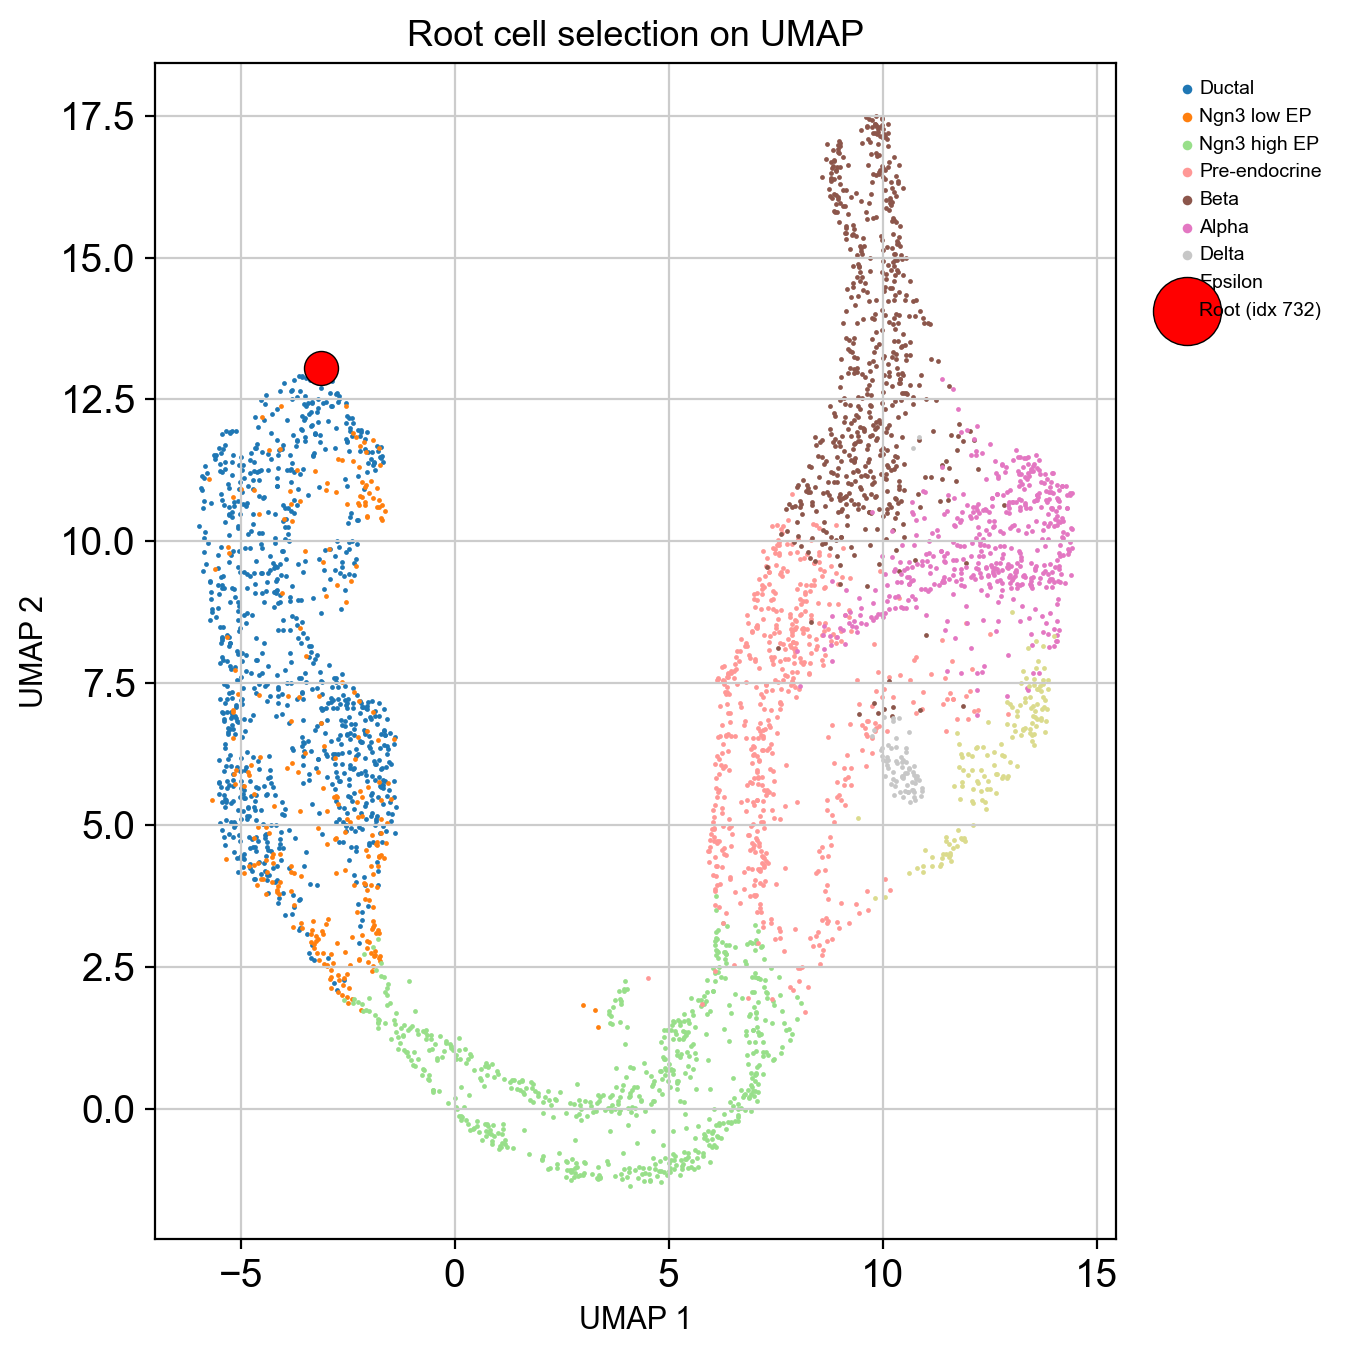

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))

if 'clusters' in adata.obs.columns:
    for cat in categories:
        mask_cat = np.array(adata.obs['clusters'] == cat)
        ax.scatter(umap[mask_cat, 0], umap[mask_cat, 1], s=3, linewidths=0,
                   color=color_map[cat], label=cat)
else:
    ax.scatter(umap[:, 0], umap[:, 1], s=3, c='lightgrey', linewidths=0)

ax.scatter(umap[root, 0], umap[root, 1], s=150, c='red', zorder=6,
           edgecolors='black', linewidths=0.5, label=f'Root (idx {root})')
ax.set_title('Root cell selection on UMAP', fontsize=13)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.legend(fontsize=7, markerscale=2,
          bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

## 4. Monocle3 Pseudotime

Monocle3 builds a principal graph (MST) on the UMAP embedding:
1. **Leiden clustering** in UMAP space identifies cell communities
2. **`learn_graph`** fits a minimum spanning tree through cluster centroids to capture the principal trajectory
3. **`order_cells`** computes pseudotime as geodesic distance along the graph from the root cell

In [7]:
sc.pp.neighbors(adata, n_neighbors=50, use_rep='X_umap')
sc.tl.leiden(adata)
leiden = adata.obs['leiden'].to_numpy(dtype=int)

print(f'Number of Leiden clusters: {leiden.max() + 1}')

/var/folders/d3/d1njg5653v572jb89sxgq3yw0000gp/T/ipykernel_14711/3191902421.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


Number of Leiden clusters: 27


In [8]:
projected_points, mst, centroids = learn_graph(matrix=umap, clusters=leiden)
pseudotime = order_cells(
    umap, centroids,
    mst=mst,
    projected_points=projected_points,
    root_cells=[root],
)
adata.obs['monocle_pseudotime'] = pseudotime
print('Pseudotime range:', pseudotime.min(), '–', pseudotime.max())

Pseudotime range: 0.0 – 46.352257162525085


/var/folders/d3/d1njg5653v572jb89sxgq3yw0000gp/T/ipykernel_14711/1056628552.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_l = plt.cm.get_cmap('tab20', n_leiden)


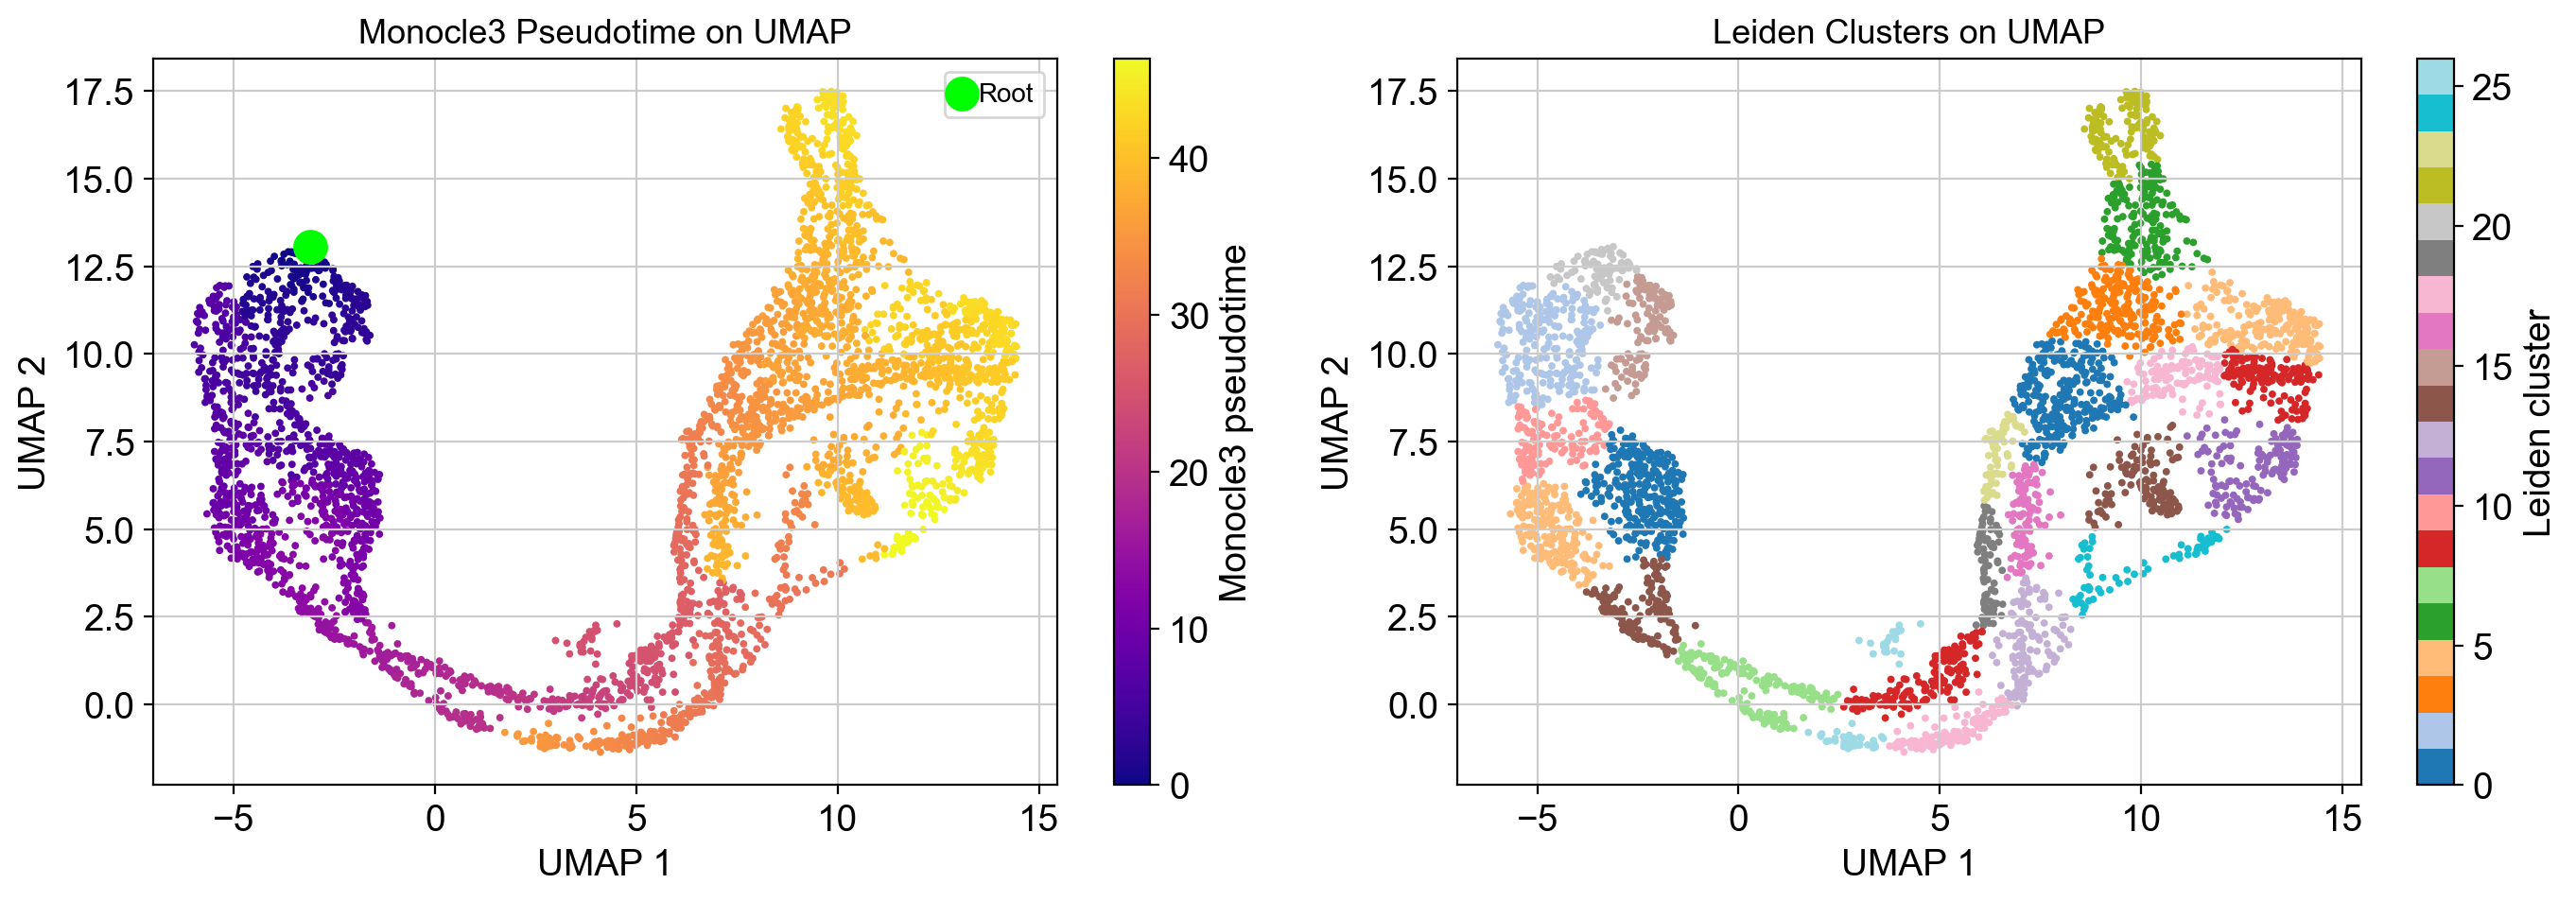

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(umap[:, 0], umap[:, 1], c=pseudotime, cmap='plasma', s=8, linewidths=0)
axes[0].scatter(umap[root, 0], umap[root, 1], s=150, c='lime', zorder=5, label='Root')
plt.colorbar(sc0, ax=axes[0], label='Monocle3 pseudotime')
axes[0].set_title('Monocle3 Pseudotime on UMAP', fontsize=13)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].legend(fontsize=10)

# Leiden clusters
n_leiden = leiden.max() + 1
cmap_l = plt.cm.get_cmap('tab20', n_leiden)
sc1 = axes[1].scatter(umap[:, 0], umap[:, 1], c=leiden, cmap='tab20',
                      vmin=0, vmax=n_leiden - 1, s=8, linewidths=0)
plt.colorbar(sc1, ax=axes[1], label='Leiden cluster')
axes[1].set_title('Leiden Clusters on UMAP', fontsize=13)
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

/var/folders/d3/d1njg5653v572jb89sxgq3yw0000gp/T/ipykernel_14711/2274591410.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('clusters')['monocle_pseudotime']


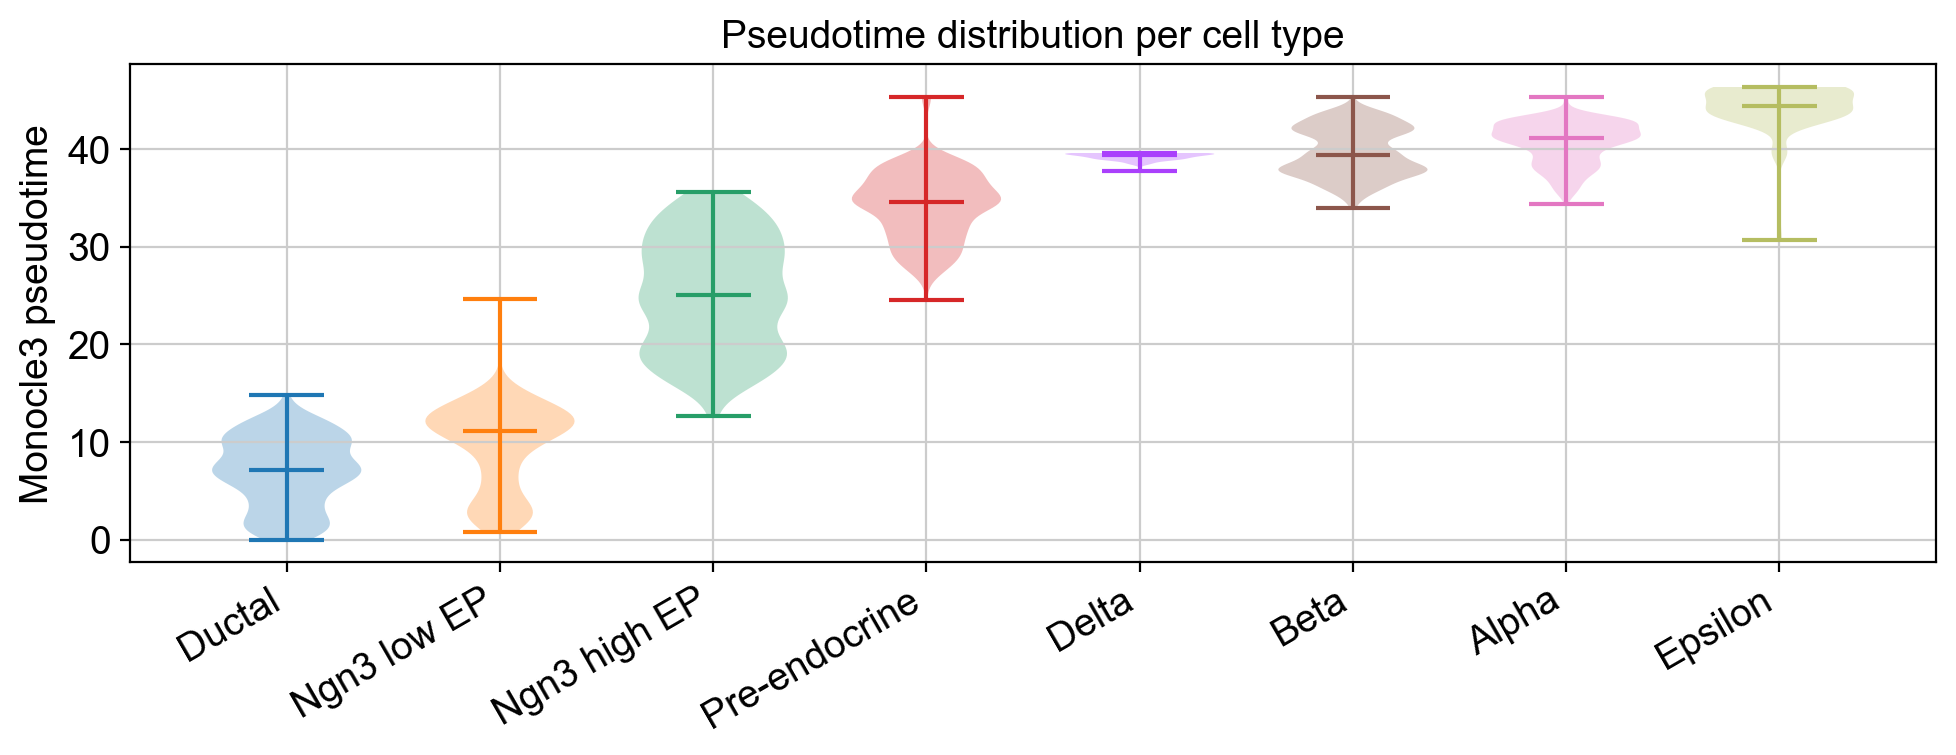

In [10]:
# Pseudotime distribution per annotated cluster
if 'clusters' in adata.obs.columns:
    cluster_order = (
        adata.obs.groupby('clusters')['monocle_pseudotime']
        .median().sort_values().index.tolist()
    )
    fig, ax = plt.subplots(figsize=(10, 4))
    for idx_c, cl in enumerate(cluster_order):
        vals = adata.obs.loc[adata.obs['clusters'] == cl, 'monocle_pseudotime']
        if len(vals) > 1:
            ax.violinplot(vals, positions=[idx_c], widths=0.7, showmedians=True)
    ax.set_xticks(range(len(cluster_order)))
    ax.set_xticklabels(cluster_order, rotation=30, ha='right')
    ax.set_ylabel('Monocle3 pseudotime')
    ax.set_title('Pseudotime distribution per cell type')
    plt.tight_layout()
    plt.show()